### BUILD A BASIC CHAT BOT USING LANG-GRAPH USING (GRAPH_API)

In [36]:
from typing_extensions import TypedDict
from typing  import Annotated
from langgraph.graph import StateGraph,START , END
from langgraph.graph.message import add_messages


In [37]:
class State(TypedDict):
    messages : Annotated[list,add_messages]
    
graph_builder  = StateGraph(State)


In [38]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [39]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
LLM = ChatGroq(
    model = "qwen/qwen3.8-27b",
    temperature = 0,
    verbose=True,
    max_tokens=800
)
LLM

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x0000022C1BA1F820>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022C1BA7C2B0>, model_name='qwen/qwen3.8-27b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None, max_tokens=800)

In [40]:
def chatbot(state:State):
    return {
        "messages":[LLM.invoke(state["messages"])]
    }

In [41]:
## add nodes to graphs
graph_builder.add_node("chatbot",chatbot)
## add edges to graph
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph = graph_builder.compile()




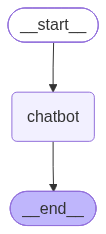

In [42]:
##visualize the graph
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
res = graph.invoke({"messages": "hello"})
res["messages"][-1]

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_time': 0.01988145, 'completion_tokens_details': None, 'prompt_time': 0.000661297, 'prompt_tokens_details': None, 'queue_time': 0.211391901, 'total_time': 0.020542747}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_61e8d148b4', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07f6e-ba0c-71b3-87c7-5a9622561bb4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23})

## Chatbot with TOOLS

In [44]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [45]:

#custom funtion 

def multiply(a:int,b:int)->int:
    """multiply a and b

    Args:
        a (int): my first int
        b (int): second int

    Returns:
        int: output 
    """
    return a*b

In [46]:
tools = [tool,multiply]
llm_with_tools = LLM.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x0000022C1BA1F820>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022C1BA7C2B0>, model_name='qwen/qwen3.8-27b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None, max_tokens=800), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Searc

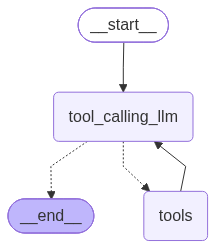

In [47]:
#creating the state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node defination
def tool_calling_llm(state:State):
    return{
        "messages":[llm_with_tools.invoke(state["messages"])]
    }

#creating the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
#adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:
res =graph.invoke({"messages":[("user","Search the web and tell me the latest OpenAI news.")]})
res["messages"][-1]

AIMessage(content='Here\'s the latest OpenAI news:\n\n**OpenAI rolls out GPT-6 Astra** (announced Thursday, Sept 3, 2026)\n\n- **The release:** OpenAI began rolling out its newest model, **GPT-6 Astra**, which the company described as the product of "years of research and big bets."\n\n- **Leadership commentary:**\n  - CEO **Sam Altman** called Astra a "new capability level" that has changed his own workflows, and said he expects "a boom of entrepreneurship, of creativity, of economic growth, of scientific discovery."\n  - President **Greg Brockman** described it as a "generational leap" and suggested it could mark the arrival of **artificial general intelligence (AGI)**, telling reporters, "Welcome to the AGI era." OpenAI defines AGI as "highly autonomous systems that outperform humans at most economically valuable work."\n\n- **Safety concerns:** There\'s growing discussion around safety, monitoring, and whether Astra is becoming harder for humans to oversee. Notably, in August OpenA

In [49]:
for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

Search the web and tell me the latest OpenAI news.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (97f6d95se)
 Call ID: 97f6d95se
  Args:
    query: latest OpenAI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest OpenAI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/09/03/open-ai-astra-gpt-6-cyber.html", "title": "OpenAI announces rollout of GPT-6 Astra model - CNBC", "content": "OpenAI on Thursday announced it will begin rolling out its latest artificial intelligence model, GPT-6 Astra, which the company said is the product of “years of research and big bets.”\n\nCEO Sam Altman told CNBC that Astra was a “new capability level” and has changed his workflows. He said he 

In [50]:
res =graph.invoke({"messages":[("user","get me the new ai models released in 2026 and multiply 2 and 3")]})
for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

get me the new ai models released in 2026 and multiply 2 and 3
================================== Ai Message ==================================

I'll help you with both tasks. Let me search for the latest AI models released in 2026 and calculate the multiplication.
Tool Calls:
  tavily_search (4hsaka3tn)
 Call ID: 4hsaka3tn
  Args:
    query: new AI models released in 2026
    search_depth: advanced
    time_range: year
  multiply (5jxaqjza7)
 Call ID: 5jxaqjza7
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "new AI models released in 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://llm-stats.com/llm-updates", "title": "AI Updates Today (September 2026) – Latest AI Model Releases", "content": "Track model releases from leading AI labs\n\nOpenAI\n\n### OpenAI\n\nGoogle\n\

## Adding memory to the agentic chatbot

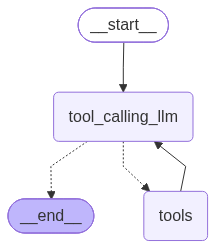

In [ ]:
#creating the state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

class State(TypedDict):
    messages : Annotated[list,add_messages]
## node defination
def tool_calling_llm(state:State):
    return{
        "messages":[llm_with_tools.invoke(state["messages"])]
    }

#creating the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
#adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
config = {"configurable":{"thread_id": "1"}}
graph.invoke({"messages":["user","my name is pramod"]},config=config)

{'messages': [HumanMessage(content='user', additional_kwargs={}, response_metadata={}, id='d1b16150-c6d7-4b13-bad2-2f072e060e10'),
  HumanMessage(content='my name is pramod', additional_kwargs={}, response_metadata={}, id='efbb0d5a-e51b-4455-86e2-c468db6a6780'),
  AIMessage(content="Hello Pramod! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1927, 'total_tokens': 1946, 'completion_time': 0.037669242, 'completion_tokens_details': None, 'prompt_time': 0.18982829, 'prompt_tokens_details': None, 'queue_time': 0.317049647, 'total_time': 0.227497532}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_921b8bf8e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07f6f-42a9-7e20-871a-e4650b3158f1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1927, 'output_tokens': 19, 'total_tokens': 1946})

In [53]:
graph.invoke({"messages":["user","what is my name"]},config=config)

{'messages': [HumanMessage(content='user', additional_kwargs={}, response_metadata={}, id='d1b16150-c6d7-4b13-bad2-2f072e060e10'),
  HumanMessage(content='my name is pramod', additional_kwargs={}, response_metadata={}, id='efbb0d5a-e51b-4455-86e2-c468db6a6780'),
  AIMessage(content="Hello Pramod! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1927, 'total_tokens': 1946, 'completion_time': 0.037669242, 'completion_tokens_details': None, 'prompt_time': 0.18982829, 'prompt_tokens_details': None, 'queue_time': 0.317049647, 'total_time': 0.227497532}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_921b8bf8e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07f6f-42a9-7e20-871a-e4650b3158f1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1927, 'output_tokens': 19, 'total_tokens': 1946})